# Day 11: Explaining a Loan Default Model with SHAP and Permutation Importance

**The big idea, told simply:** we have a robot that looks at a person asking for a loan and says "this person will probably pay us back" or "this person might not." A robot that just says yes or no is scary. We want to ask it: **why did you say that?**

This notebook opens up the robot and looks inside. We use two tools:

1. **Permutation importance**: "What happens to the robot's score if we mess up one clue?"
2. **SHAP**: "How much did each clue push the answer up or down, for each single person?"

At the end we check that the robot's reasons make sense, because a model that is right for the wrong reasons is not safe to use.

## Step 0: Get our tools ready

Think of this as taking crayons and paper out of the bag before we start drawing. Nothing fancy happens here.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
IMG = "images/"

## Step 1: Make a pretend town of loan applicants

**Why we make our own data:** if we make the data ourselves, we know the real secret rules behind who defaults. That is like knowing the answer key before a test. Later we can check if the explanation tools found the same secrets we planted.

The secret rules we planted:

- A **low credit score** makes default more likely.
- **Many late payments** make default more likely.
- A **big loan compared to income** makes default more likely.
- **High debt compared to income** makes default more likely.
- A **cosigner** (a grown-up who promises to help pay) makes default less likely.
- **More years at a job** makes default a little less likely.

Two clues are on purpose useless: `random_noise` (just random numbers) and `num_credit_cards` (has no effect at all). `age` has no direct effect either.

One more trick: `monthly_income_reported` is almost a copy of `annual_income` divided by 12. Two clues saying the same thing will confuse some tools. We want to see how.

In [2]:
n = 8000
rng = np.random.default_rng(RANDOM_STATE)

age = np.clip(rng.normal(38, 11, n), 21, 70)
annual_income = np.clip(rng.lognormal(mean=np.log(55000), sigma=0.45, size=n), 15000, 300000)
monthly_income_reported = annual_income / 12 * (1 + rng.normal(0, 0.02, n))
employment_years = np.clip(rng.uniform(0, 1, n) * (age - 20), 0, 40)
credit_score = np.clip(rng.normal(660, 70, n) + 0.5 * employment_years, 300, 850)
loan_to_income = rng.uniform(0.05, 0.8, n)
loan_amount = annual_income * loan_to_income
debt_to_income = np.clip(rng.normal(0.30, 0.10, n), 0.02, 0.8)
late_rate = 0.5 + np.clip((700 - credit_score) / 100, 0, None) * 1.2
num_late_payments = np.clip(rng.poisson(late_rate), 0, 12)
num_credit_cards = np.clip(rng.poisson(2.5, n), 0, 10)
has_cosigner = rng.binomial(1, 0.2, n)
random_noise = rng.normal(0, 1, n)

logit = (
    -2.6
    + 3.0 * loan_to_income
    + 4.0 * (debt_to_income - 0.30)
    - 0.012 * (credit_score - 660)
    + 0.35 * num_late_payments
    - 0.04 * employment_years
    - 0.8 * has_cosigner
)
prob_default = 1 / (1 + np.exp(-logit))
defaulted = rng.binomial(1, prob_default)

df = pd.DataFrame({
    "age": age.round(0),
    "annual_income": annual_income.round(0),
    "monthly_income_reported": monthly_income_reported.round(0),
    "employment_years": employment_years.round(1),
    "credit_score": credit_score.round(0),
    "loan_amount": loan_amount.round(0),
    "debt_to_income": debt_to_income.round(3),
    "num_late_payments": num_late_payments,
    "num_credit_cards": num_credit_cards,
    "has_cosigner": has_cosigner,
    "random_noise": random_noise.round(3),
    "defaulted": defaulted,
})
df.to_csv("data/synthetic_loan_applicants.csv", index=False)

print("Rows:", len(df))
print("Share of people who defaulted:", round(df["defaulted"].mean(), 3))
df.head()

Rows: 8000
Share of people who defaulted: 0.253


,age,annual_income,monthly_income_reported,employment_years,credit_score,loan_amount,debt_to_income,num_late_payments,num_credit_cards,has_cosigner,random_noise,defaulted
0,41.0,63909.0,5185.0,1.0,707.0,44430.0,0.376,1,5,0,-0.192,0
1,27.0,95937.0,8217.0,3.9,642.0,44843.0,0.343,0,0,1,0.038,0
2,46.0,95055.0,7866.0,17.4,698.0,50796.0,0.376,0,1,0,-0.322,0
3,48.0,44898.0,3736.0,5.7,633.0,4143.0,0.152,0,1,0,-1.272,0
4,21.0,60018.0,5030.0,0.8,717.0,33144.0,0.452,1,2,0,0.030,1


## Step 2: Teach two robots

Same as Day 8, we keep a simple robot and a stronger robot side by side:

- **Logistic regression** is the simple robot. It just adds up clues with weights.
- **LightGBM** is the strong robot. It asks many small yes/no questions in a row, like a very long game of 20 Questions.

We put some people aside as a **test group** that the robots never see while learning. That is like keeping a surprise quiz separate from homework. All our explanations use this test group, because we care about how the robot behaves on people it has not met.

In [3]:
features = [c for c in df.columns if c != "defaulted"]
X = df[features]
y = df["defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

simple_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
simple_model.fit(X_train, y_train)

model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=15,
    min_child_samples=40, subsample=0.8, subsample_freq=1,
    colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1,
)
model.fit(X_train, y_train)

def score(m, name):
    p = m.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_test, p),
        "pr_auc": average_precision_score(y_test, p),
        "f1_at_0.5": f1_score(y_test, (p >= 0.5).astype(int)),
    }

results = pd.DataFrame([score(simple_model, "Logistic Regression"), score(model, "LightGBM")]).round(3)
results

,model,roc_auc,pr_auc,f1_at_0.5
0,Logistic Regression,0.796,0.612,0.507
1,LightGBM,0.793,0.592,0.520


Both robots score about the same. That is not a surprise, because we wrote the secret rules in a simple add-up style, so the simple robot fits them naturally. The scores are only there to prove the robot is worth explaining. **A good score does not tell us if the robot is thinking the right way.** That is what the rest of the notebook is for.

From here on, "the robot" means the LightGBM model.

## Step 3: The easy but sneaky way, the built-in importance

LightGBM can tell us how many times it used each clue when asking questions (or how much each clue helped). It is free and quick. But it is like asking a student "which textbook chapter did you read the most?" That does not tell you which chapter actually helped them pass the test.

Let us look at it anyway, so we can compare it with the better tools later.

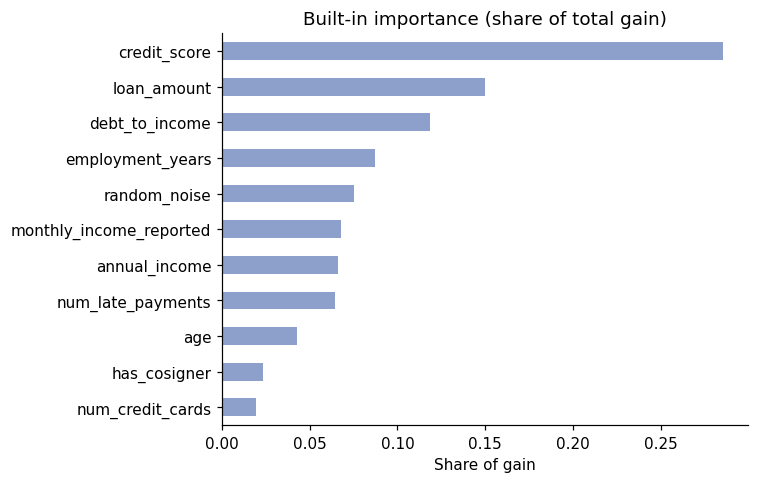

In [4]:
gain_importance = pd.Series(
    model.booster_.feature_importance(importance_type="gain"), index=features
)
gain_importance = (gain_importance / gain_importance.sum()).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
gain_importance.plot.barh(ax=ax, color="#8da0cb")
ax.set_title("Built-in importance (share of total gain)")
ax.set_xlabel("Share of gain")
plt.tight_layout()
plt.savefig(IMG + "01_builtin_gain_importance.png", bbox_inches="tight")
plt.show()

## Step 4: Permutation importance, the "mess up one crayon" test

**How it works, for a 5 year old:** imagine you have a drawing made with many crayon colors. To find out which color matters most, you take one color and scramble it so it lands in random places. If the picture suddenly looks terrible, that color was very important. If the picture looks the same, that color did not matter.

For our robot: we take one clue column (say `credit_score`), shuffle it among the test people so it no longer matches the right person, and see how much the robot's score drops. We repeat this 20 times per clue so we do not trust a lucky shuffle. The bars below show the average drop and how wobbly it is.

We use the **test group**, not the training group, so we measure what the robot really relies on when it meets new people.

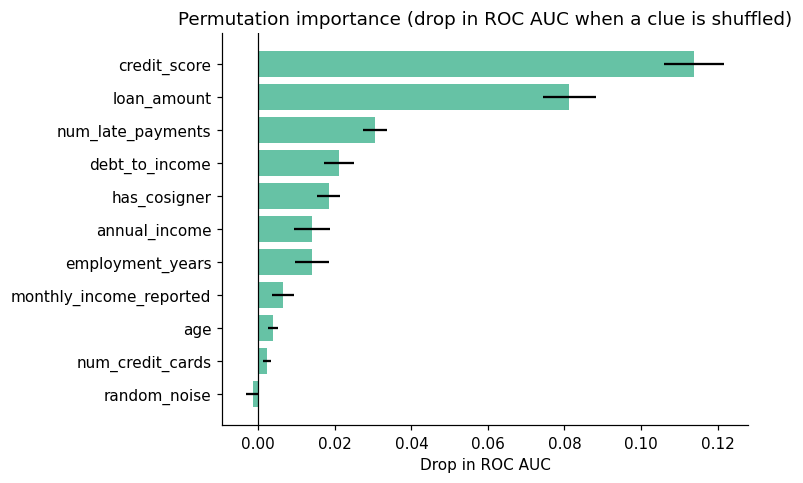

,feature,auc_drop_mean,auc_drop_std
0,credit_score,0.1139,0.0078
1,loan_amount,0.0813,0.0069
2,num_late_payments,0.0305,0.0031
3,debt_to_income,0.0211,0.0040
4,has_cosigner,0.0183,0.0031
5,annual_income,0.0140,0.0047
6,employment_years,0.0140,0.0045
7,monthly_income_reported,0.0064,0.0030
8,age,0.0038,0.0013
9,num_credit_cards,0.0023,0.0010


In [5]:
perm = permutation_importance(
    model, X_test, y_test, scoring="roc_auc",
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": features,
    "auc_drop_mean": perm.importances_mean,
    "auc_drop_std": perm.importances_std,
}).sort_values("auc_drop_mean")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(perm_df["feature"], perm_df["auc_drop_mean"], xerr=perm_df["auc_drop_std"], color="#66c2a5")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Permutation importance (drop in ROC AUC when a clue is shuffled)")
ax.set_xlabel("Drop in ROC AUC")
plt.tight_layout()
plt.savefig(IMG + "02_permutation_importance.png", bbox_inches="tight")
plt.show()

perm_df.sort_values("auc_drop_mean", ascending=False).round(4).reset_index(drop=True)

**What to notice:**

- The big bars are the clues the robot really leans on.
- Bars near zero mean the robot ignores that clue. `random_noise` should sit there, and it does. That is a good sign.
- Look at `annual_income` and `monthly_income_reported`. They say the same thing, so when we shuffle one, the robot can still peek at the other. Their bars look smaller than they should. We come back to this in Step 8.

## Step 5: SHAP, "who gets how many slices of the pizza"

**How it works, for a 5 year old:** imagine a group of friends bakes one big pizza together, and the pizza is the robot's final answer. Some friends did a lot of the work and some only a little. SHAP is a very fair way to decide how many slices each friend gets, by checking what the pizza would look like with and without each friend in every possible team.

For our robot, each clue is a friend. For every single person, SHAP says: "credit score pushed the risk up by this much, late payments pushed it up by that much, having a cosigner pushed it down by this much." All the pushes add up to the robot's final answer for that person.

One small thing: for this model SHAP measures pushes in **log-odds**, which is just a stretched version of probability. Positive push means more risk of default. Negative push means less risk.

In [6]:
explainer = shap.TreeExplainer(model)
shap_exp = explainer(X_test)

# Some versions return one set of values per class. We want the "will default" class.
if shap_exp.values.ndim == 3:
    shap_exp = shap_exp[:, :, 1]

print("SHAP values shape (people, clues):", shap_exp.values.shape)

# Sanity check: base value plus all pushes should rebuild the robot's own raw score.
raw_from_shap = shap_exp.base_values + shap_exp.values.sum(axis=1)
raw_from_model = model.predict(X_test, raw_score=True)
print("Max difference between SHAP rebuild and model score:",
      float(np.abs(raw_from_shap - raw_from_model).max()))

SHAP values shape (people, clues): (2000, 11)
Max difference between SHAP rebuild and model score: 1.2656542480726785e-14


The tiny difference above is our proof that SHAP is honest: base guess plus every clue's push equals what the robot actually said.

### The global picture: which clues matter most overall?

We take the average size of each clue's push across all test people. Big average push means big overall importance.

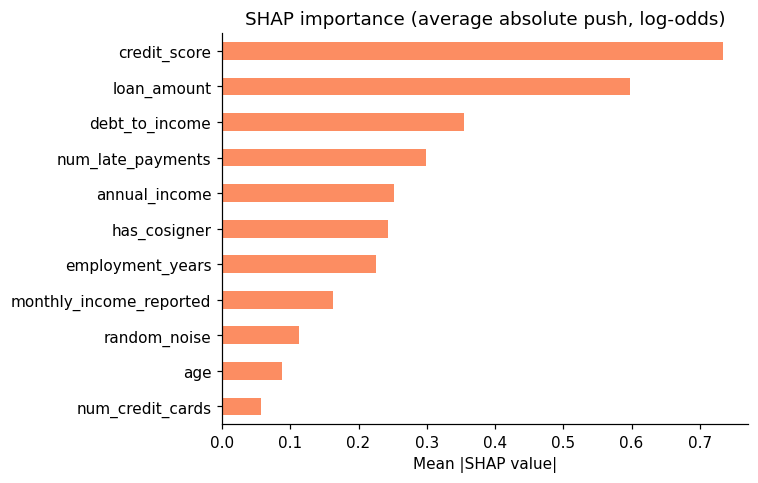

In [7]:
shap_global = pd.Series(np.abs(shap_exp.values).mean(axis=0), index=features).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
shap_global.plot.barh(ax=ax, color="#fc8d62")
ax.set_title("SHAP importance (average absolute push, log-odds)")
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig(IMG + "03_shap_global_bar.png", bbox_inches="tight")
plt.show()

### The beeswarm: direction matters, not just size

Each dot is one person. Left of the middle line means the clue lowered their risk. Right means it raised their risk. The color shows if that person's value for the clue was low (blue) or high (red).

Read it like a story. For `credit_score`, red dots (high scores) should sit on the left, because a high score means lower risk. For `num_late_payments`, red dots (many late payments) should sit on the right.

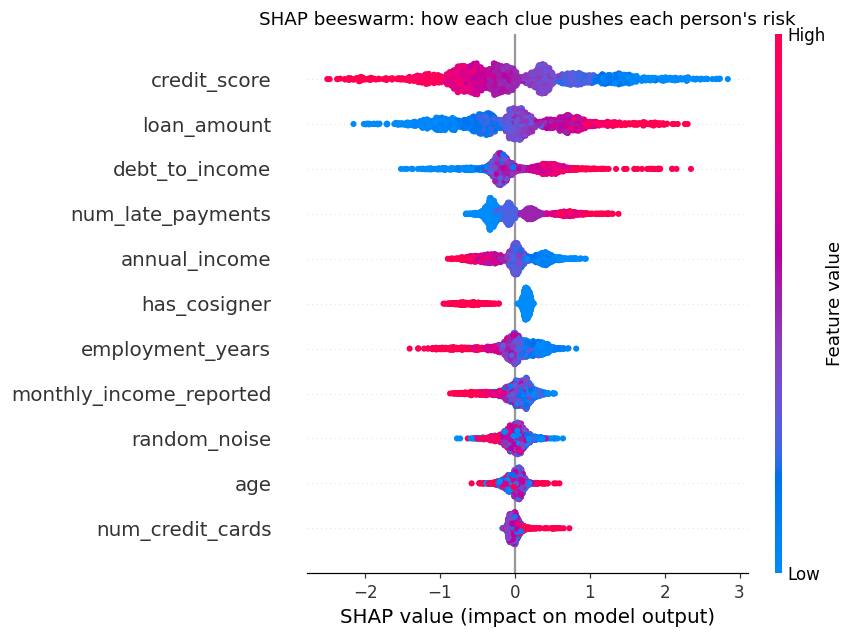

In [8]:
plt.figure()
shap.plots.beeswarm(shap_exp, max_display=len(features), show=False)
plt.title("SHAP beeswarm: how each clue pushes each person's risk")
plt.tight_layout()
plt.savefig(IMG + "04_shap_beeswarm.png", bbox_inches="tight")
plt.show()

### One clue up close: credit score

This plot puts credit score on the bottom and its push on the side. We planted a rule where a higher score always lowers risk. If the robot learned that, the dots should slope downward from left to right.

<Figure size 704x528 with 0 Axes>

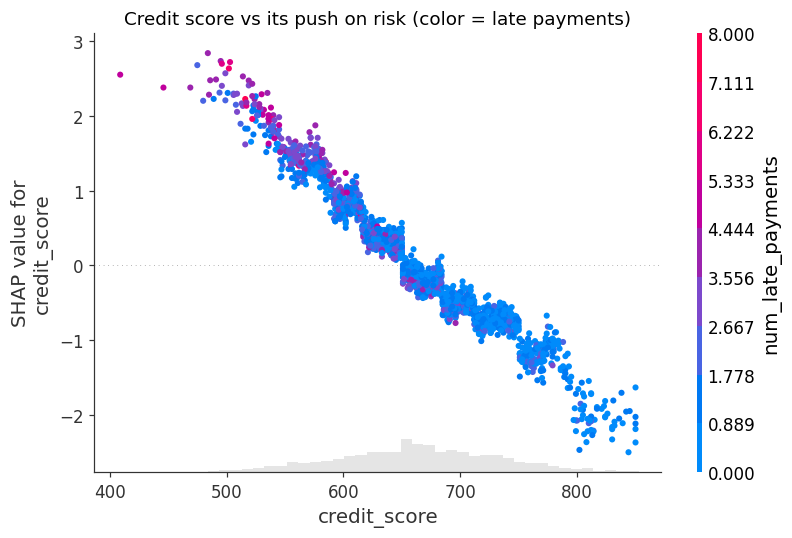

In [9]:
plt.figure()
shap.plots.scatter(shap_exp[:, "credit_score"], color=shap_exp[:, "num_late_payments"], show=False)
plt.title("Credit score vs its push on risk (color = late payments)")
plt.tight_layout()
plt.savefig(IMG + "05_shap_dependence_credit_score.png", bbox_inches="tight")
plt.show()

## Step 6: Explain one person at a time

This is the part a bank customer or a manager actually cares about. Someone asks, "Why was my loan flagged?" We can now answer with a real reason instead of "the computer said so."

We pick the test person the robot thinks is **most risky** and the one it thinks is **safest**, and draw a waterfall for each. A waterfall starts at the average guess and then shows each clue stepping the answer up or down until it reaches the final answer.

Riskiest person predicted default probability: 0.984
{'age': 25.0, 'annual_income': 89982.0, 'monthly_income_reported': 7646.0, 'employment_years': 2.9, 'credit_score': 576.0, 'loan_amount': 59285.0, 'debt_to_income': 0.522, 'num_late_payments': 3.0, 'num_credit_cards': 3.0, 'has_cosigner': 0.0, 'random_noise': -1.365}


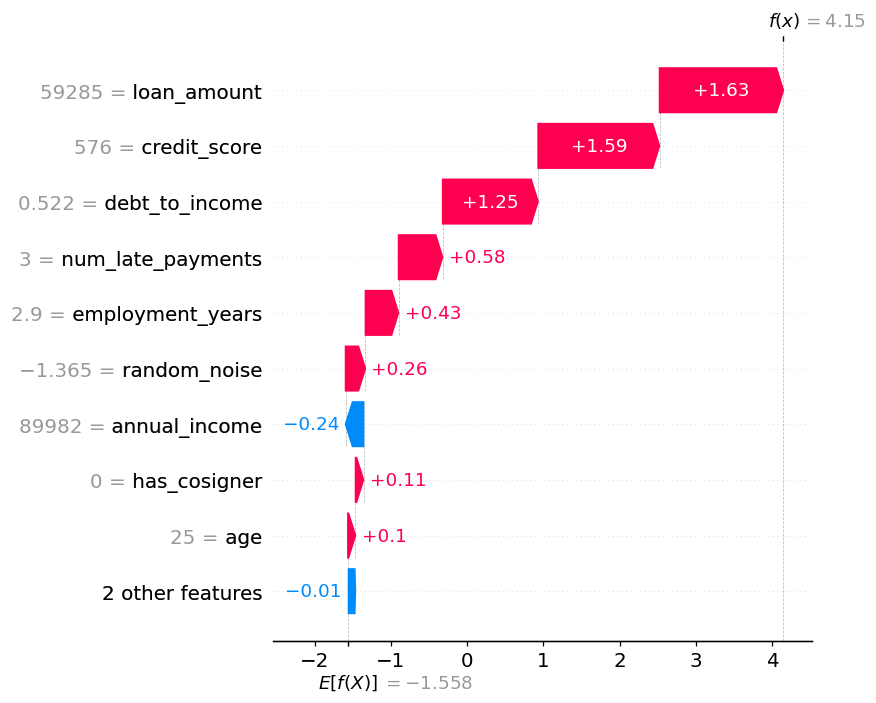

In [10]:
proba = model.predict_proba(X_test)[:, 1]
riskiest_idx = int(np.argmax(proba))
safest_idx = int(np.argmin(proba))

print("Riskiest person predicted default probability:", round(float(proba[riskiest_idx]), 3))
print(X_test.iloc[riskiest_idx].to_dict())
plt.figure()
shap.plots.waterfall(shap_exp[riskiest_idx], max_display=10, show=False)
plt.tight_layout()
plt.savefig(IMG + "06_waterfall_riskiest.png", bbox_inches="tight")
plt.show()

Safest person predicted default probability: 0.003
{'age': 22.0, 'annual_income': 128372.0, 'monthly_income_reported': 10783.0, 'employment_years': 1.7, 'credit_score': 769.0, 'loan_amount': 30028.0, 'debt_to_income': 0.146, 'num_late_payments': 0.0, 'num_credit_cards': 5.0, 'has_cosigner': 1.0, 'random_noise': 2.568}


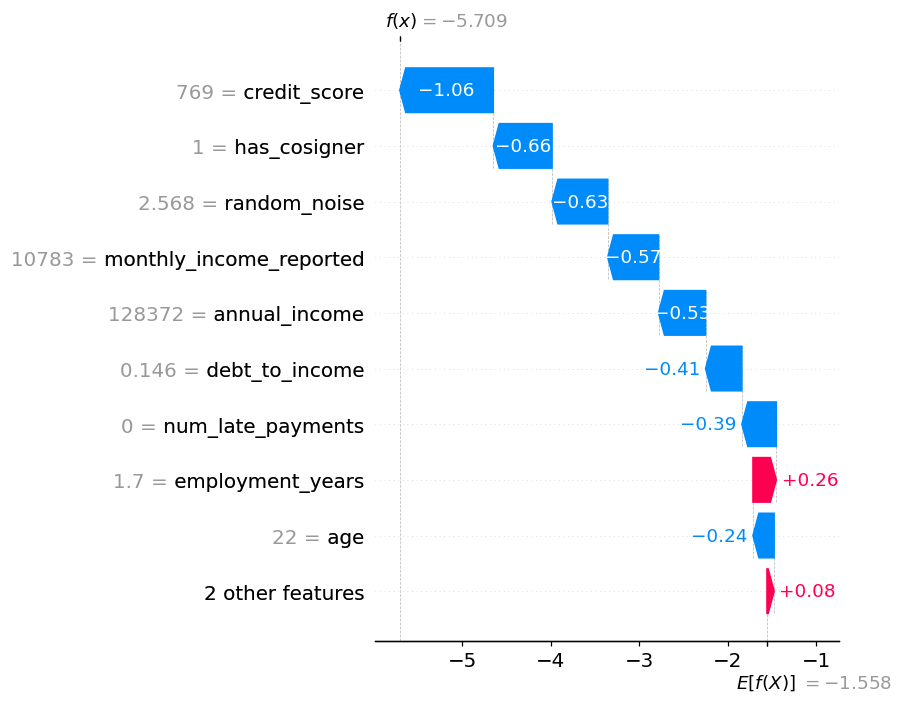

In [11]:
print("Safest person predicted default probability:", round(float(proba[safest_idx]), 3))
print(X_test.iloc[safest_idx].to_dict())
plt.figure()
shap.plots.waterfall(shap_exp[safest_idx], max_display=10, show=False)
plt.tight_layout()
plt.savefig(IMG + "07_waterfall_safest.png", bbox_inches="tight")
plt.show()

**Reading the two waterfalls:** in the riskiest person, a big loan, a low credit score, and heavy debt all push the answer up. In the safest person, the opposite happens. That is exactly the story we would want to tell a loan officer.

**One honest surprise:** look for `random_noise` in these charts. It should mean nothing, yet it gets a small push for some people. That means the robot memorized a tiny bit of luck from the training data. This is called overfitting. The push is small, but per-person explanations are a good way to catch it.

## Step 7: Do the tools agree with each other, and with the answer key?

Now we put all three importance rankings next to each other, and next to what we know is true because we planted it. If different tools tell very different stories, we should be careful.

We turn each measure into a rank (1 means most important) so they are easy to compare.

In [12]:
compare = pd.DataFrame({
    "gain_rank": gain_importance.rank(ascending=False),
    "permutation_rank": perm_df.set_index("feature")["auc_drop_mean"].rank(ascending=False),
    "shap_rank": shap_global.rank(ascending=False),
}).astype(int)

planted = {
    "credit_score": "planted: strong",
    "num_late_payments": "planted: strong",
    "debt_to_income": "planted: medium",
    "loan_amount": "planted: strong (via loan / income ratio)",
    "annual_income": "planted: strong (via loan / income ratio)",
    "has_cosigner": "planted: medium",
    "employment_years": "planted: small",
    "monthly_income_reported": "planted: none (copy of income)",
    "age": "planted: none",
    "num_credit_cards": "planted: none",
    "random_noise": "planted: none",
}
compare["what_we_planted"] = pd.Series(planted)
compare = compare.sort_values("shap_rank")
compare.to_csv("data/importance_rank_comparison.csv")
compare

,gain_rank,permutation_rank,shap_rank,what_we_planted
credit_score,1,1,1,planted: strong
loan_amount,2,2,2,planted: strong (via loan / income ratio)
debt_to_income,3,4,3,planted: medium
num_late_payments,8,3,4,planted: strong
annual_income,7,6,5,planted: strong (via loan / income ratio)
has_cosigner,10,5,6,planted: medium
employment_years,4,7,7,planted: small
monthly_income_reported,6,8,8,planted: none (copy of income)
random_noise,5,11,9,planted: none
age,9,9,10,planted: none


**How to read this table:** rank 1 means most important. Good signs are strong planted clues near the top and "none" clues near the bottom. Small shuffles in the middle are normal, because each tool answers a slightly different question.

- **Built-in gain** asks: "which clues did the robot use to split people into groups?"
- **Permutation importance** asks: "how much does the score fall if this clue is broken?"
- **SHAP** asks: "how much did this clue push the answers?"

Two things to notice:

- **Compare the built-in ranking with the other two.** Look at where it puts `random_noise` and `has_cosigner`. A column of pure random numbers should not get a respectable rank.
- **The loan-to-income idea is split across two columns.** We planted a rule about loan size compared to income, but the robot only sees `loan_amount` and `annual_income` separately. So the credit for one idea is shared between two columns.

## Step 8: The twin problem (two clues that say the same thing)

We gave the robot `annual_income` and a near copy called `monthly_income_reported`. Watch what permutation importance does with twins.

When we shuffle `annual_income`, the robot can lean on its twin, so the score barely drops. When we shuffle the twin, the same thing happens. So **both twins look less important than they really are**. That is a known weakness, and it is the kind of thing that fools people who only use one tool.

A simple fix is to shuffle the twins **together as a group**. If the group's drop is large, the information they share matters a lot.

In [13]:
def grouped_permutation(model, X, y, columns, n_repeats=20, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    base = roc_auc_score(y, model.predict_proba(X)[:, 1])
    drops = []
    for _ in range(n_repeats):
        Xp = X.copy()
        order = rng.permutation(len(X))
        Xp[columns] = X[columns].values[order]   # same shuffle for the whole group keeps the twins together
        drops.append(base - roc_auc_score(y, model.predict_proba(Xp)[:, 1]))
    return float(np.mean(drops)), float(np.std(drops))

single = perm_df.set_index("feature")["auc_drop_mean"]
group_mean, group_std = grouped_permutation(model, X_test, y_test, ["annual_income", "monthly_income_reported"])

twin_table = pd.DataFrame({
    "what_we_shuffled": ["annual_income alone", "monthly_income_reported alone", "both together as a group"],
    "auc_drop": [single["annual_income"], single["monthly_income_reported"], group_mean],
}).round(4)
twin_table

,what_we_shuffled,auc_drop
0,annual_income alone,0.0140
1,monthly_income_reported alone,0.0064
2,both together as a group,0.0344


If the group drop is clearly bigger than the two single drops, the twins were hiding each other. In real projects this happens all the time, for example with "zip code" and "city", or "total price" and "price per unit". The lesson: **when two clues are related, judge them together.**

SHAP has its own version of this problem. When twins carry the same information, the robot uses them interchangeably, and SHAP hands out credit to both. Below we look at how much credit the useless twin gets. Remember: in our answer key, `monthly_income_reported` has **no** effect of its own.

In [14]:
print("SHAP importance for the twin clues:")
print(shap_global[["annual_income", "monthly_income_reported"]].round(4))
print()
print("Correlation between the twins:",
      round(float(X_test["annual_income"].corr(X_test["monthly_income_reported"])), 4))

SHAP importance for the twin clues:
annual_income              0.2517
monthly_income_reported    0.1632
dtype: float64

Correlation between the twins: 0.999


Notice that the useless twin still gets a large share of credit in SHAP. Nothing is wrong with SHAP here. It is telling the truth about the **robot**: the robot really does use that column, because it is a stand-in for income. But it does not tell us that monthly income has its own effect in the real world. In our answer key it does not.

**Lesson:** an importance number says "the model uses this," not "this causes the result." Always keep that sentence in your head.

## Step 9: Do the explanations tell the truth? A drop-the-clue check

Explanations are claims. Claims should be tested. Here is a simple test: **take a clue away completely and retrain the robot from scratch.**

- If the tools said a clue is important, the score should fall a lot when we remove it.
- If the tools said a clue is useless, the score should barely move.

We test the clue the tools ranked at the top, the two they ranked at the very bottom, and the pure random noise clue.

In [15]:
top_feature = shap_global.sort_values(ascending=False).index[0]
bottom_features = list(shap_global.sort_values().index[:2])
print("Top clue by SHAP:", top_feature)
print("Bottom clues by SHAP:", bottom_features)

def retrain_without(cols):
    keep = [c for c in features if c not in cols]
    m = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=15,
        min_child_samples=40, subsample=0.8, subsample_freq=1,
        colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1,
    )
    m.fit(X_train[keep], y_train)
    return roc_auc_score(y_test, m.predict_proba(X_test[keep])[:, 1])

full_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
rows = [{"removed": "nothing (full model)", "roc_auc": full_auc}]
tested = list(dict.fromkeys([top_feature] + bottom_features + ["random_noise"]))
for c in tested:
    rows.append({"removed": c, "roc_auc": retrain_without([c])})
drop_check = pd.DataFrame(rows)
drop_check["change_vs_full"] = drop_check["roc_auc"] - full_auc
drop_check.round(4)

Top clue by SHAP: credit_score
Bottom clues by SHAP: ['num_credit_cards', 'age']


,removed,roc_auc,change_vs_full
0,nothing (full model),0.7925,0.0000
1,credit_score,0.7547,-0.0378
2,num_credit_cards,0.7865,-0.0060
3,age,0.7854,-0.0071
4,random_noise,0.7891,-0.0035


If removing the top clue hurts a lot and removing the bottom clues changes very little in comparison, the explanations passed the test. Tiny wiggles up or down for the useless clues are just noise from retraining. This is the same idea as a science experiment: we made a prediction ("this clue matters") and then checked it.

## Step 10: Why any of this matters (the grown-up part, still simple)

**Trust.** If a loan officer sees that the robot's top reasons are late payments, credit score, and debt, they can say "yes, that is how I would think too." If the top reason turned out to be `random_noise` or a customer ID, we would know something is broken, even if the score looked great.

**Fairness and rules.** In many places, a person who is turned down for a loan has a right to a reason. Per-person SHAP explanations like the waterfalls above are one way to give that reason. Also, if a clue like age or zip code shows up as a big driver, that is a signal to stop and check for unfair treatment.

**Debugging.** Explanations are a flashlight. If the beeswarm shows a clue pushing in the wrong direction (for example, more late payments lowering risk), we probably have a data bug, a leak, or a mislabeled column.

**Deployment.** Before shipping a model, we can write down "these are the clues it uses and this is how it uses them," and later watch if that story changes in the real world. If the top clues suddenly change, the world changed or the data pipeline broke.

### Honest limits of what we did

- The data is made up. Real data is messier, and real explanations are less clean.
- SHAP and permutation importance describe **what the model does**, not **what causes default in real life**. A clue can matter to the model without being the real cause.
- Correlated clues can hide or split importance, as we saw with the income twins.
- We explained one model with one random split. A stronger check would repeat this on several splits.

### What I would improve next

1. Run the same analysis on real, public loan data and compare the story to this made-up version.
2. Repeat over several train and test splits and show how stable the rankings are.
3. Add SHAP interaction values to see which clues work as a team (for example, loan size together with income).
4. Add a small fairness check by comparing errors across age groups.
5. Wrap the per-person explanation in the FastAPI endpoint from Day 12, so every prediction comes with its top three reasons.